# Smart Lender - Loan Approval Prediction

## AIM
To build a machine learning model that predicts whether a loan application will be approved based on the applicant's information.

---

## Workflow

1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Feature Engineering
6. Model Building
7. Model Evaluation
8. Save the Best Model
9. Flask Web Application
10. Deployment

In [88]:
# ===============================================
# Smart Lender Project
# Import Required Libraries
# ===============================================

import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

sns.set_style("whitegrid")

print("✅ Libraries Imported Successfully")


✅ Libraries Imported Successfully


## Load the Dataset

The loan prediction dataset is loaded into a Pandas DataFrame for analysis and preprocessing.

In [89]:
# Load the dataset

df = pd.read_csv("../Dataset/loan_prediction.csv")

print("✅ Dataset Loaded Successfully")

✅ Dataset Loaded Successfully


## Display the First Five Records

In [90]:
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Dataset Shape

In [91]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 614
Number of Columns: 13


## Dataset Features

In [92]:
df.columns


Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

## Dataset Information

In [93]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


## Statistical Summary

In [94]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


## Missing Values

In [95]:
df.isnull().sum()


Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

## Check Duplicate Records


In [96]:
 
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


## data types of features


In [97]:
df.dtypes

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

In [98]:
categorical_columns = df.select_dtypes(include='object').columns
numerical_columns = df.select_dtypes(exclude='object').columns

print("Categorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numerical_columns)

Categorical Columns:
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area', 'Loan_Status'],
      dtype='str')

Numerical Columns:
Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='str')


In [99]:
df["Loan_Status"].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

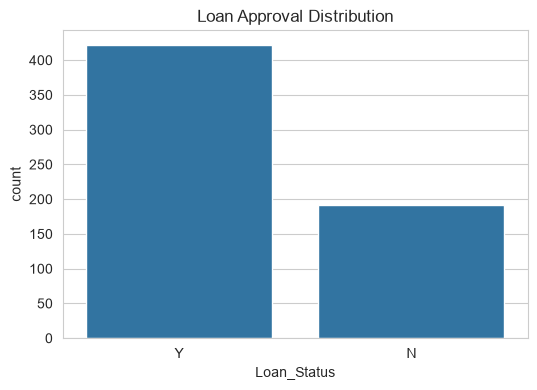

In [100]:
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=df)

plt.title("Loan Approval Distribution")
plt.show()

In [101]:
for column in categorical_columns:
    print("="*40)
    print(column)
    print(df[column].value_counts())

Loan_ID
Loan_ID
LP001002    1
LP001003    1
LP001005    1
LP001006    1
LP001008    1
LP001011    1
LP001013    1
LP001014    1
LP001018    1
LP001020    1
LP001024    1
LP001027    1
LP001028    1
LP001029    1
LP001030    1
LP001032    1
LP001034    1
LP001036    1
LP001038    1
LP001041    1
LP001043    1
LP001046    1
LP001047    1
LP001050    1
LP001052    1
LP001066    1
LP001068    1
LP001073    1
LP001086    1
LP001087    1
LP001091    1
LP001095    1
LP001097    1
LP001098    1
LP001100    1
LP001106    1
LP001109    1
LP001112    1
LP001114    1
LP001116    1
LP001119    1
LP001120    1
LP001123    1
LP001131    1
LP001136    1
LP001137    1
LP001138    1
LP001144    1
LP001146    1
LP001151    1
LP001155    1
LP001157    1
LP001164    1
LP001179    1
LP001186    1
LP001194    1
LP001195    1
LP001197    1
LP001198    1
LP001199    1
LP001205    1
LP001206    1
LP001207    1
LP001213    1
LP001222    1
LP001225    1
LP001228    1
LP001233    1
LP001238    1
LP001241    1
LP00

## Relationship Between Features and Loan Status 

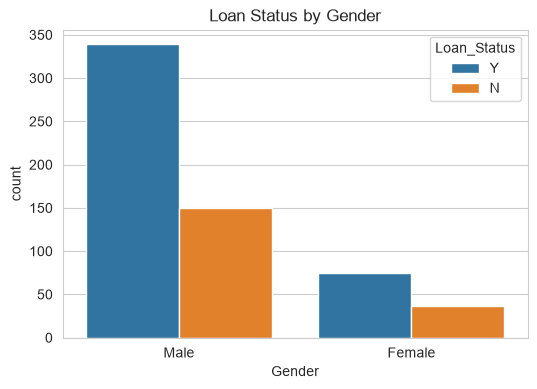

In [102]:
# Gender vs Loan Status
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Loan_Status', data=df)
plt.title("Loan Status by Gender")
plt.show()

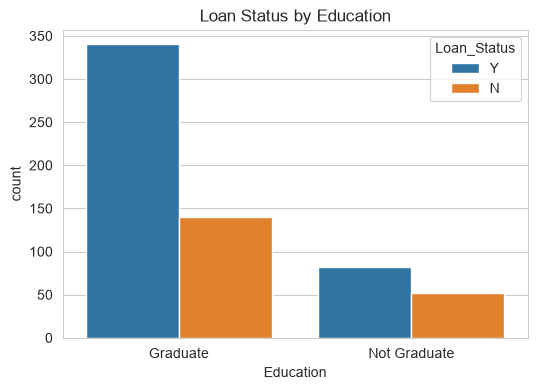

In [103]:
# Education vs Loan Status
plt.figure(figsize=(6,4))
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.title("Loan Status by Education")
plt.show()

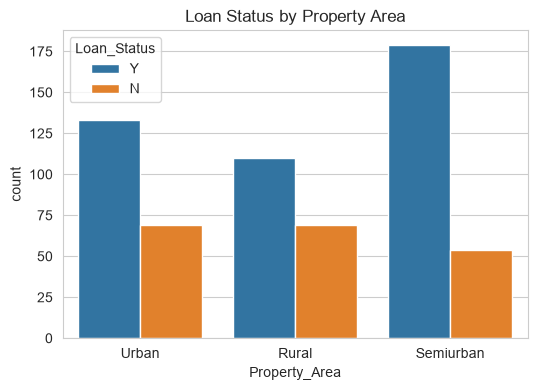

In [104]:
# Property Area vs Loan Status
plt.figure(figsize=(6,4))
sns.countplot(x='Property_Area', hue='Loan_Status', data=df)
plt.title("Loan Status by Property Area")
plt.show()

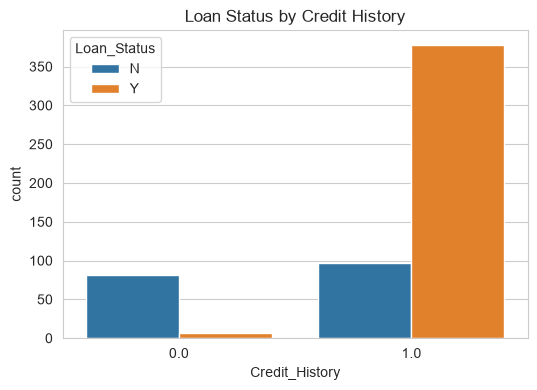

In [105]:
# Credit History vs Loan Status
plt.figure(figsize=(6,4))
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title("Loan Status by Credit History")
plt.show()

## Relationship Between Features and Loan Status


Gender vs Loan Status

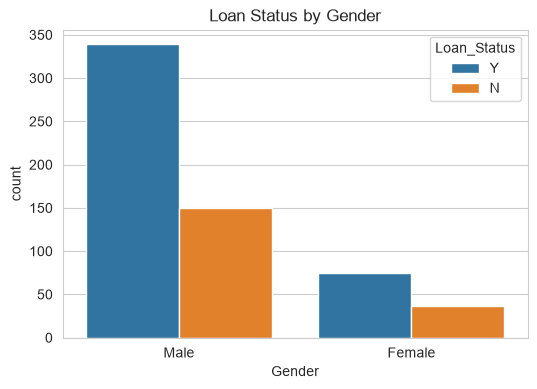

In [106]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Loan_Status', data=df)
plt.title("Loan Status by Gender")
plt.show()

Education vs Loan Status


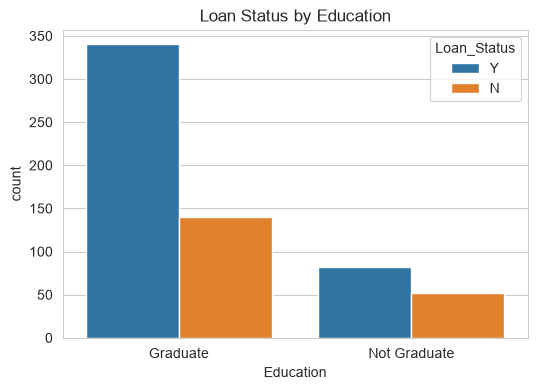

In [107]:
plt.figure(figsize=(6,4))
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.title("Loan Status by Education")
plt.show()

Property Area vs Loan Status

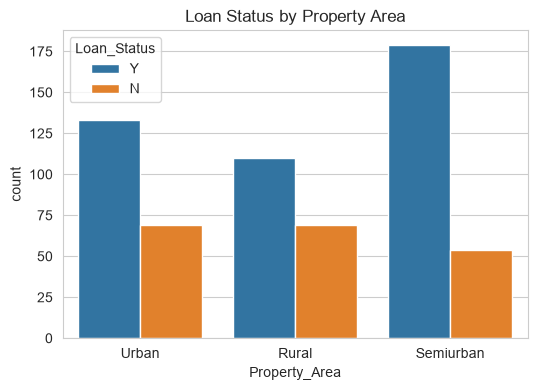

In [108]:
plt.figure(figsize=(6,4))
sns.countplot(x='Property_Area', hue='Loan_Status', data=df)
plt.title("Loan Status by Property Area")
plt.show()

Credit History vs Loan Status

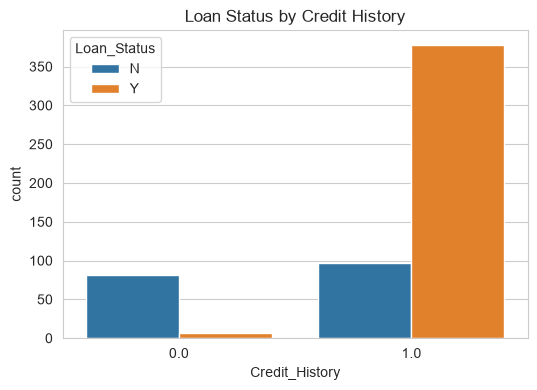

In [109]:
plt.figure(figsize=(6,4))
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title("Loan Status by Credit History")
plt.show()

## Numerical Feature Analysis

Applicant Income

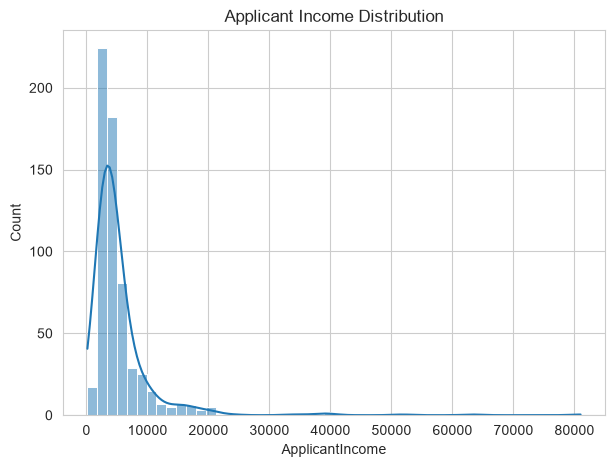

In [110]:
plt.figure(figsize=(7,5))
sns.histplot(df["ApplicantIncome"], kde=True)
plt.title("Applicant Income Distribution")
plt.show()

Loan Amount

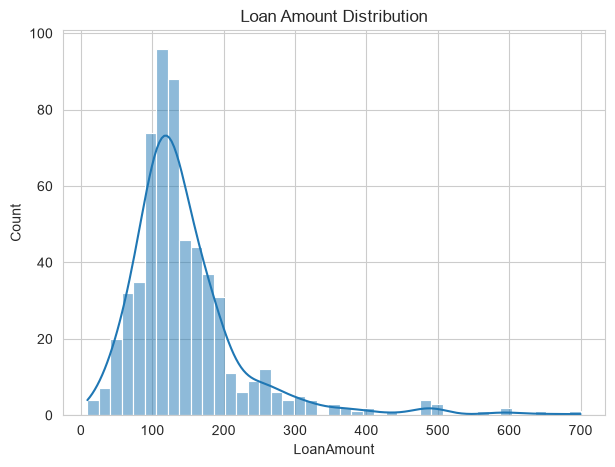

In [111]:
plt.figure(figsize=(7,5))
sns.histplot(df["LoanAmount"], kde=True)
plt.title("Loan Amount Distribution")
plt.show()

Loan Amount Boxplot

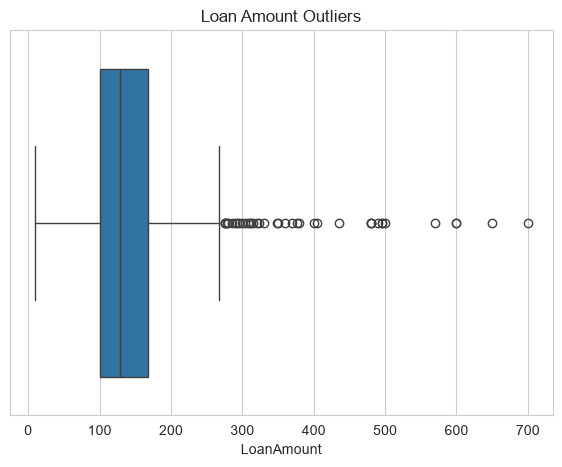

In [112]:
plt.figure(figsize=(7,5))
sns.boxplot(x=df["LoanAmount"])
plt.title("Loan Amount Outliers")
plt.show()

Income vs Loan Amount

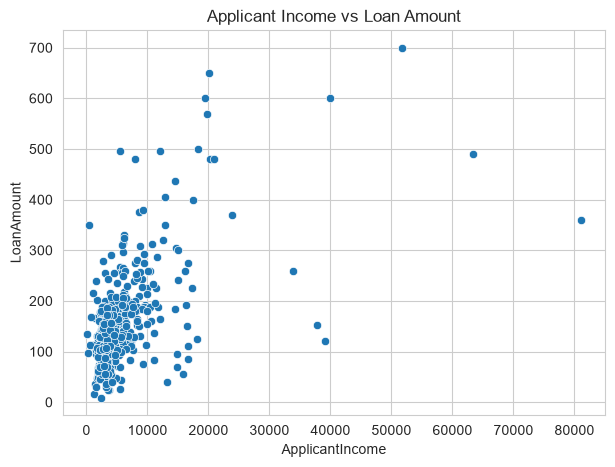

In [113]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='ApplicantIncome', y='LoanAmount', data=df)
plt.title("Applicant Income vs Loan Amount")
plt.show()

## Correlation Heatmap (Numerical Features)

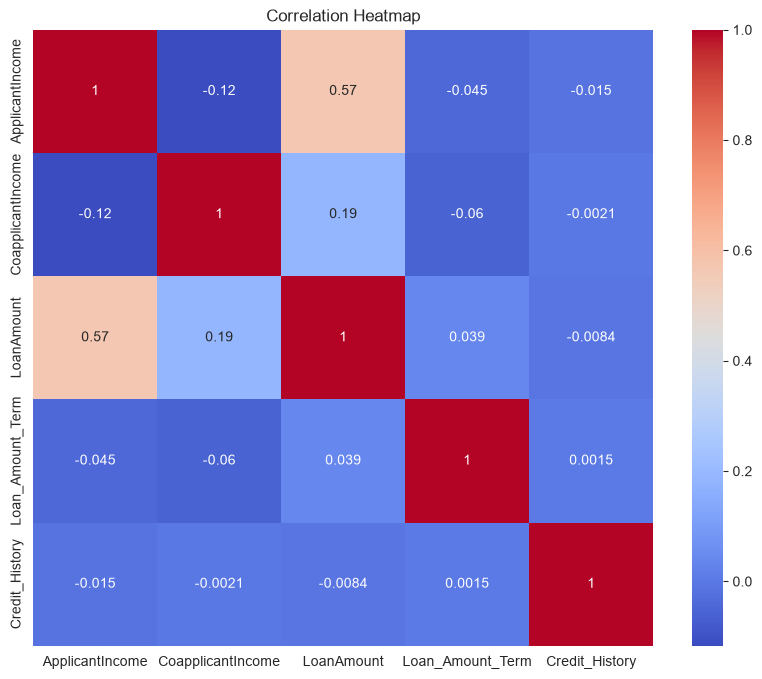

In [114]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=['number']).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

## Data Preprocessing

In [115]:
# Create a copy of the dataset
data = df.copy()

# Display first five rows
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [116]:
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Fill Missing Values

Categorical Columns

In [117]:
data["Gender"] = data["Gender"].fillna(data["Gender"].mode()[0])
data["Married"] = data["Married"].fillna(data["Married"].mode()[0])
data["Dependents"] = data["Dependents"].fillna(data["Dependents"].mode()[0])
data["Self_Employed"] = data["Self_Employed"].fillna(data["Self_Employed"].mode()[0])

Numerical Columns

In [118]:
data["LoanAmount"] = data["LoanAmount"].fillna(data["LoanAmount"].median())
data["Loan_Amount_Term"] = data["Loan_Amount_Term"].fillna(data["Loan_Amount_Term"].mode()[0])
data["Credit_History"] = data["Credit_History"].fillna(data["Credit_History"].mode()[0])

In [119]:
data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [120]:
# Remove Loan_ID column
data = data.drop("Loan_ID", axis=1)

# Verify
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [121]:
data.dtypes

Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

## Encode Categorical Variables

In [122]:
from sklearn.preprocessing import LabelEncoder

In [123]:
encoder = LabelEncoder()

In [124]:
categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Loan_Status"
]

for column in categorical_columns:
    data[column] = encoder.fit_transform(data[column])

In [125]:
categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Loan_Status"
]

for column in categorical_columns:
    data[column] = encoder.fit_transform(data[column])

## Verify the Dataset

In [126]:
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


## Verify Data Types

In [127]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    int64  
 1   Married            614 non-null    int64  
 2   Dependents         614 non-null    int64  
 3   Education          614 non-null    int64  
 4   Self_Employed      614 non-null    int64  
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    int64  
 11  Loan_Status        614 non-null    int64  
dtypes: float64(4), int64(8)
memory usage: 57.7 KB


Correlation Matrix

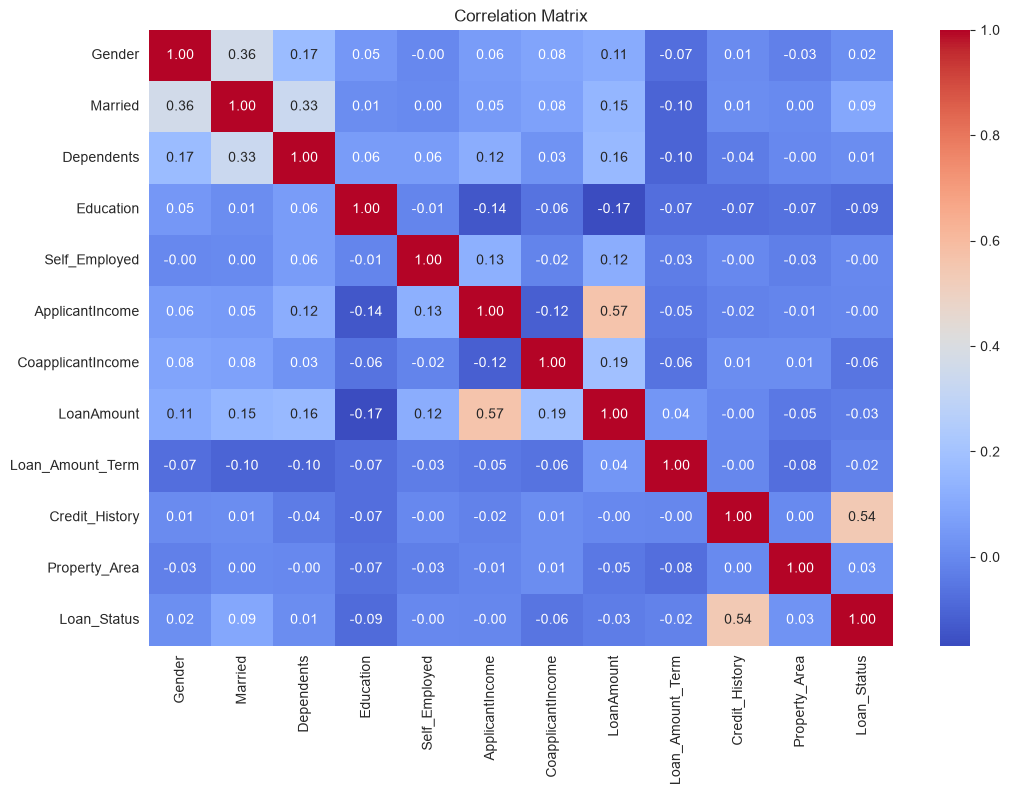

In [128]:
plt.figure(figsize=(12,8))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

## Model Preparation

In [129]:
# Features
X = data.drop("Loan_Status", axis=1)

# Target
y = data["Loan_Status"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (614, 11)
Target Shape: (614,)


In [130]:
# Split the Dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (491, 11)
Testing Data: (123, 11)


In [131]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [132]:
#Train Logistic Regression
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [133]:
# Make Predictions
lr_predictions = lr_model.predict(X_test_scaled)

In [134]:
# evaluate model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, lr_predictions)

print("Accuracy:", accuracy) 

Accuracy: 0.7886178861788617


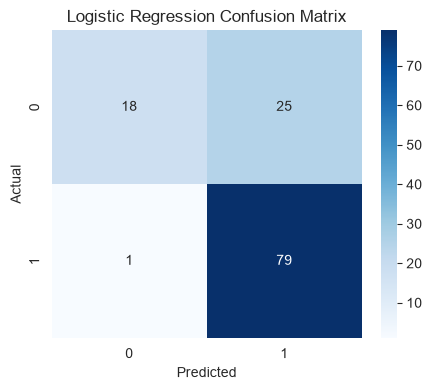

In [135]:
#Confusion Matrix
cm = confusion_matrix(y_test, lr_predictions)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()


In [136]:
#classification report
print(classification_report(y_test, lr_predictions))

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



## Decision Tree Classifier

In [137]:
#import decision tree
from sklearn.tree import DecisionTreeClassifier

In [138]:
#Create the Model
dt_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

In [139]:
dt_model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [140]:
dt_predictions = dt_model.predict(X_test)

In [141]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, dt_predictions)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.6910569105691057


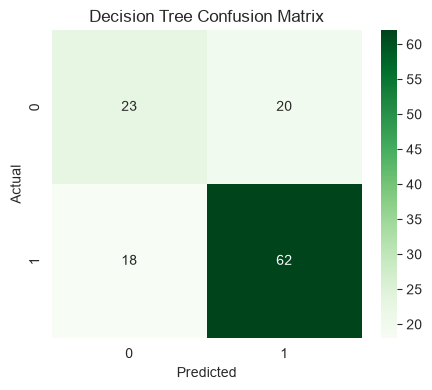

In [142]:
cm = confusion_matrix(y_test, dt_predictions)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

In [143]:
print(classification_report(y_test, dt_predictions))

              precision    recall  f1-score   support

           0       0.56      0.53      0.55        43
           1       0.76      0.78      0.77        80

    accuracy                           0.69       123
   macro avg       0.66      0.65      0.66       123
weighted avg       0.69      0.69      0.69       123



## Train Random Forest

In [144]:
from sklearn.ensemble import RandomForestClassifier

In [145]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [146]:
rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [147]:
rf_predictions = rf_model.predict(X_test)

In [148]:
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7560975609756098


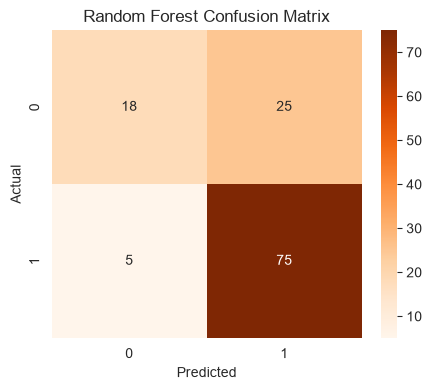

In [149]:
cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [150]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.78      0.42      0.55        43
           1       0.75      0.94      0.83        80

    accuracy                           0.76       123
   macro avg       0.77      0.68      0.69       123
weighted avg       0.76      0.76      0.73       123



## K-Nearest Neighbors (KNN)

In [151]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)

In [152]:
knn_model.fit(X_train_scaled, y_train)

print("KNN Model Trained Successfully")

KNN Model Trained Successfully


In [153]:
knn_predictions = knn_model.predict(X_test_scaled)

In [154]:
knn_accuracy = accuracy_score(y_test, knn_predictions)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.7560975609756098


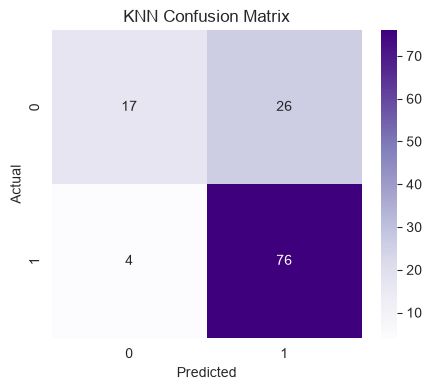

In [155]:
cm = confusion_matrix(y_test, knn_predictions)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Purples")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")

plt.show()

In [156]:
print(classification_report(y_test, knn_predictions))

              precision    recall  f1-score   support

           0       0.81      0.40      0.53        43
           1       0.75      0.95      0.84        80

    accuracy                           0.76       123
   macro avg       0.78      0.67      0.68       123
weighted avg       0.77      0.76      0.73       123



## XGBoost Classifier

In [157]:
from xgboost import XGBClassifier

In [158]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

In [159]:
xgb_model.fit(X_train, y_train)

print("XGBoost Model Trained Successfully")

XGBoost Model Trained Successfully


In [160]:
xgb_predictions = xgb_model.predict(X_test)

In [161]:
xgb_accuracy = accuracy_score(y_test, xgb_predictions)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.7642276422764228


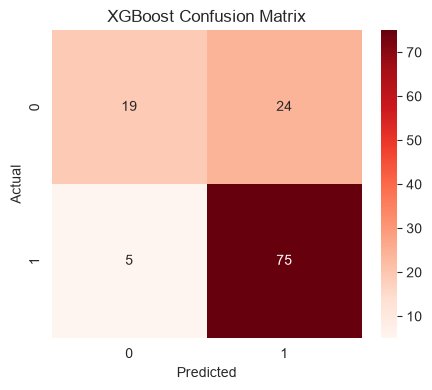

In [162]:
cm = confusion_matrix(y_test, xgb_predictions)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()

In [163]:
print(classification_report(y_test, xgb_predictions))

              precision    recall  f1-score   support

           0       0.79      0.44      0.57        43
           1       0.76      0.94      0.84        80

    accuracy                           0.76       123
   macro avg       0.77      0.69      0.70       123
weighted avg       0.77      0.76      0.74       123



In [164]:
results = {
    "Logistic Regression": accuracy,
    "Decision Tree": dt_accuracy,
    "Random Forest": rf_accuracy,
    "KNN": knn_accuracy,
    "XGBoost": xgb_accuracy
}

comparison = pd.DataFrame(
    results.items(),
    columns=["Model", "Accuracy"]
)

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison

,Model,Accuracy
0,Logistic Regression,0.788618
4,XGBoost,0.764228
2,Random Forest,0.756098
3,KNN,0.756098
1,Decision Tree,0.691057


## Visualize Model Comparison

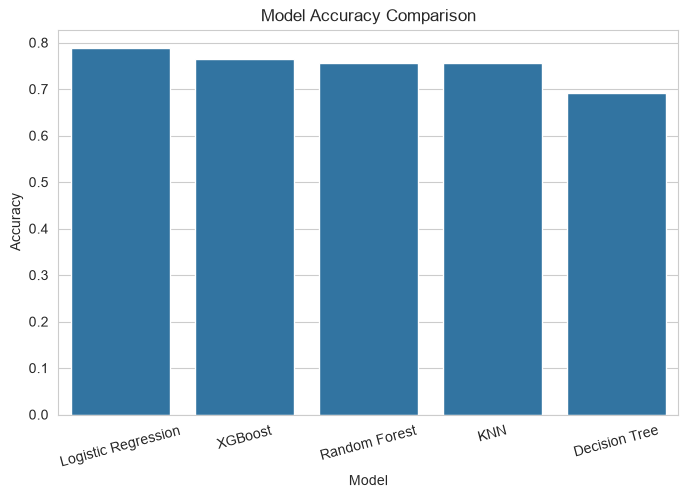

In [165]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)

plt.show()

In [86]:
import os
os.makedirs("models", exist_ok=True)

In [166]:
import joblib

joblib.dump(lr_model, "models/model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

print("Model and Scaler Saved Successfully!")

Model and Scaler Saved Successfully!
